# StreamView Analytics — Análisis Exploratorio del Catálogo Audiovisual
### Caso Semestral — Visualización de Datos 

**Equipo consultor:** Visual Analytics
**Fuentes de datos:** netflix_movies_detailed_up_to_2025.csv,netflix_tv_shows_detailed_up_to_2025.csv

Este notebook documenta la integración de fuentes, la revisión de calidad de datos,
el cálculo de KPIs y el análisis exploratorio mediante visualizaciones requerido en la Etapa 1
del proyecto.

---
## Marco de Negocio y Audiencia Objetivo

* **Stakeholder clave:** Gerencia de Adquisición y Gestión de Contenidos.
* **Rol en el negocio:** Responsable de evaluar oportunidades de adquisición, negociar licencias con productoras y estudios internacionales, definir el balance y composición del catálogo y decidir en qué géneros o países invertir para futuras compras y renovaciones.
* **Problema específico que enfrenta:** Toma de decisiones basada en reportes fragmentados y criterios dispares, careciendo de visibilidad consolidada sobre qué combinaciones de género y país entregan alta valoración y popularidad con una inversión financiera razonable.
* **Propósito comunicacional de la solución:** Proveer una base analítico-visual exploratoria que identifique nichos estratégicos de contenido, desmitifique la relación entre consumo masivo y satisfacción crítica, y evalúe la eficiencia del presupuesto de adquisición cinematográfica (ROI).
---

## 1. Carga de datos

In [1]:
from ast import literal_eval
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Configuración de estilo y paletas corporativas
sns.set_theme(style='whitegrid')
PALETTE = 'Blues_r'
COLOR_ACCENT = '#d62728'
COLOR_PRIMARY = '#1f77b4'

# Carpeta para almacenar imágenes generadas para el informe
os.makedirs('../images', exist_ok=True)

In [2]:
!wget https://raw.githubusercontent.com/VeritoCR/StreamView-Analytics/refs/heads/main/data/netflix_movies_detailed_up_to_2025.csv
!wget https://raw.githubusercontent.com/VeritoCR/StreamView-Analytics/refs/heads/main/data/netflix_tv_shows_detailed_up_to_2025.csv

movies = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")
tvshows = pd.read_csv("netflix_tv_shows_detailed_up_to_2025.csv")

--2026-09-09 05:31:57--  https://raw.githubusercontent.com/VeritoCR/StreamView-Analytics/refs/heads/main/data/netflix_movies_detailed_up_to_2025.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7855963 (7.5M) [text/plain]
Saving to: ‘netflix_movies_detailed_up_to_2025.csv.5’

netflix_movies_deta 100%[===================>]   7.49M  34.6MB/s    in 0.2s    

2026-09-09 05:32:00 (34.6 MB/s) - ‘netflix_movies_detailed_up_to_2025.csv.5’ saved [7855963/7855963]

--2026-09-09 05:32:02--  https://raw.githubusercontent.com/VeritoCR/StreamView-Analytics/refs/heads/main/data/netflix_tv_shows_detailed_up_to_2025.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercont

In [3]:
print(f"Películas:  {movies.shape[0]:,} registros | {movies.shape[1]} variables")
print(f"Series:     {tvshows.shape[0]:,} registros | {tvshows.shape[1]} variables")

Películas:  16,000 registros | 18 variables
Series:     16,000 registros | 16 variables


In [4]:
movies.head(5)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [5]:
tvshows.head(5)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600
3,75685,TV Show,Prostřeno!,NaN,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,1 Seasons,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500
4,33847,TV Show,The Talk,NaN,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,1 Seasons,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400


## 3. Integración de las fuentes de datos

Ambos datasets comparten 16 atributos estructurales: show_id,type,title, director,cast,country,date_added,release_year,rating,duration,genres, language,description,popularity,vote_count, y vote_average.

### ¿Por qué agregamos budget y revenue vacíos a series?
1.Establecen que *budget* y *revenue* se utilizarán exclusivamente para películas, y que ante variables no disponibles se debe excluir o explicitar la limitación. No deben rellenarse con 0 porque falsearían las métricas financieras (ROI, promedios).
2.Si se concatena buscando solo las columnas comunes existentes sin crearlas en series previamente,common_cols descartaría budget y revenue, borrando las finanzas de las películas. Al asignarlas como NaN, se consolida un catálogo maestro de 32.000 registros y 18 columnas estándar.

In [6]:
# Aseguramos columnas comunes; agregamos budget/revenue vacíos a series
for col in ["budget", "revenue"]:
    if col not in tvshows.columns:
        tvshows[col] = np.nan

common_cols = [c for c in movies.columns if c in tvshows.columns]
catalogo = pd.concat([movies[common_cols], tvshows[common_cols]], ignore_index=True)

print(f"Catálogo integrado: {catalogo.shape[0]:,} registros | {catalogo.shape[1]} variables")
catalogo['type'].value_counts()

Catálogo integrado: 32,000 registros | 18 variables


type
Movie      16000
TV Show    16000
Name: count, dtype: int64

## 3. Calidad de los datos

In [7]:
# Tabla de auditoría de calidad
tabla_nulos = pd.DataFrame({
    'Total Nulos': catalogo.isna().sum(),
    '% Nulos': (catalogo.isna().mean() * 100).round(1),
}).sort_values(by='Total Nulos', ascending=False)
# Mostramos solo las columnas que presentan datos faltantes
tabla_nulos[tabla_nulos['Total Nulos'] > 0]

,Total Nulos,% Nulos
budget,16000,50.0
duration,16000,50.0
revenue,16000,50.0
director,11097,34.7
description,3338,10.4
country,2263,7.1
cast,1361,4.3
genres,1081,3.4


In [8]:
por_anio = catalogo.groupby(['release_year','type']).size().unstack()
print("Rango de registros por año y tipo (2010-2025):")
print(por_anio.loc[2010:2025].agg(['min','max']))


Rango de registros por año y tipo (2010-2025):
type  Movie  TV Show
min    1000     1000
max    1000     1000


- `budget` y `revenue` están nulos en el 100% de las series (esperado).
- `director` presenta nulos relevantes, coherente con producciones colaborativas o de reality/talk shows.
- Se revisan duplicados por `show_id` (clave primaria) y formatos inconsistentes en `duration` y `genres`.
- **Limitación relevante:** el catálogo contiene exactamente 1.000 películas y 1.000 series por cada año
  entre 2010 y 2025. Esta uniformidad perfecta indica que los datos fueron balanceados artificialmente
  para fines académicos y no representan el volumen real de estrenos de la industria; por lo tanto,
  los análisis de "evolución del catálogo" deben interpretarse como composición del catálogo por año,
  no como crecimiento real de producción.

In [9]:
# ==============================================================================
# AUDITORÍA Y RESOLUCIÓN DE IDENTIFICADORES (show_id)
# ==============================================================================
dup_movies = movies.duplicated(subset="show_id").sum()
dup_tv = tvshows.duplicated(subset="show_id").sum()
colisiones_id = len(set(movies["show_id"]).intersection(set(tvshows["show_id"])))
total_dup_catalogo = catalogo.duplicated(subset="show_id").sum()

# Generación de clave primaria compuesta para garantizar unicidad referencial
catalogo["unique_content_id"] = catalogo["type"].str.upper().str.replace(" ", "_") + "_" + catalogo["show_id"].astype(str)
dup_compuesta = catalogo.duplicated(subset="unique_content_id").sum()

# Resumen ejecutivo de integridad de claves
tabla_auditoria_id = pd.DataFrame({
    "Métrica de Integridad": [
        "Duplicados puros en Películas",
        "Duplicados redundantes en Series (año 2025)",
        "Colisiones de ID entre Películas y Series (TMDB)",
        "Total colisiones en catálogo consolidado",
        "Duplicados residuales tras aplicar 'unique_content_id'"
    ],
    "Registros": [dup_movies, dup_tv, colisiones_id, total_dup_catalogo, dup_compuesta]
})

tabla_auditoria_id

,Métrica de Integridad,Registros
0,Duplicados puros en Películas,0
1,Duplicados redundantes en Series (año 2025),9
2,Colisiones de ID entre Películas y Series (TMDB),397
3,Total colisiones en catálogo consolidado,406
4,Duplicados residuales tras aplicar 'unique_con...,9


Al consolidar las fuentes en un catálogo único, se detectan **406 filas con identificadores repetidos** en la columna `show_id`. La auditoría detallada demuestra que no se trata de 406 contenidos duplicados, sino de dos situaciones con causas y tratamientos distintos.

1. **Colisiones de numeración entre películas y series (397 casos):**
   Las fuentes originales de películas y series provienen de extracciones con secuencias numéricas independientes. Como resultado, 397 identificadores coinciden por azar entre ambas tablas identificando obras completamente distintas .No representan duplicidad de contenido, sino una colisión de claves generada al unir dos tablas que usaban el mismo rango numérico.

2. **Duplicados reales por error de carga en series (9 casos):**
   Existen 9 registros en el archivo de series que fueron cargados dos veces con idénticos valores en todas sus variables (incluyendo show_id). Estos casos sí corresponden a registros redundantes originados en la extracción de la fuente.

**Desición**
Para evitar que una película y una serie se mezclen o se cuenten como el mismo registro al cargar los datos en Power BI o Tableau, se creó una clave única llamada `unique_content_id`. Esta columna junta el formato con el número original. 

De esta manera, cada contenido queda con un identificador propio e irrepetible, solucionando las 397 coincidencias numéricas y dejando solo las 9 series duplicadas identificadas para su depuración.

In [10]:
# Transformaciones de variables
def parse_duration(row):
  val = row['duration']
  if pd.isna(val):
    return np.nan
  val = str(val)
  if 'min' in val:
    return float(val.replace('min', '').strip())
  return np.nan


def parse_seasons(row):
  val = row['duration']
  if pd.isna(val):
    return np.nan
  val = str(val)
  if 'Season' in val:
    return float(val.split()[0])
  return np.nan


catalogo['duration_min'] = catalogo.apply(parse_duration, axis=1)
catalogo['seasons'] = catalogo.apply(parse_seasons, axis=1)

# Extracción de categoría y país principal
catalogo['genero_principal'] = (
    catalogo['genres'].dropna().apply(lambda x: str(x).split(',')[0].strip())
)
catalogo['pais_principal'] = (
    catalogo['country'].dropna().apply(lambda x: str(x).split(',')[0].strip())
)

# Fechas
catalogo['date_added'] = pd.to_datetime(
    catalogo['date_added'], errors='coerce'
)
catalogo['anio_incorporacion'] = catalogo['date_added'].dt.year

# Coherencia budget/revenue (solo películas, Regla de Negocio N° 6)
pelis = catalogo[catalogo['type'] == 'Movie'].copy()
con_finanzas = pelis[(pelis['budget'] > 0) & (pelis['revenue'] > 0)]
print(
    f'Películas con budget y revenue > 0: {len(con_finanzas):,} de'
    f' {len(pelis):,} ({len(con_finanzas)/len(pelis)*100:.1f}%)'
)
print('El resto se excluye de los análisis financieros corporativos.')

Películas con budget y revenue > 0: 3,540 de 16,000 (22.1%)
El resto se excluye de los análisis financieros corporativos.


## 4. Indicadores Clave de Desempeño (KPIs)

In [11]:
kpis_catalogo = {
    'Total de contenidos': len(catalogo),
    'Total de películas': (catalogo['type'] == 'Movie').sum(),
    'Total de series': (catalogo['type'] == 'TV Show').sum(),
    'Países representados': catalogo['pais_principal'].nunique(),
    'Idiomas disponibles': catalogo['language'].nunique(),
    'Géneros distintos': catalogo['genero_principal'].nunique(),
    'Popularidad promedio': round(catalogo['popularity'].mean(), 2),
    'Calificación promedio (vote_average)': round(
        catalogo['vote_average'].mean(), 2
    ),
    'Películas con finanzas válidas': len(con_finanzas),
    'Tasa de retorno positivo en películas (%)': round(
        (con_finanzas['revenue'] > con_finanzas['budget']).mean() * 100, 1
    ),
}
pd.Series(kpis_catalogo, name='Valor').to_frame()

,Valor
Total de contenidos,32000.00
Total de películas,16000.00
Total de series,16000.00
Países representados,122.00
Idiomas disponibles,83.00
Géneros distintos,28.00
Popularidad promedio,42.62
Calificación promedio (vote_average),5.69
Películas con finanzas válidas,3540.00
Tasa de retorno positivo en películas (%),63.20


Esta tabla resume los números generales del catálogo unificado y deja varios puntos clave para las decisiones de adquisición.
El catálogo está dividido en partes exactamente iguales. Esto confirma que los datos fueron armados de manera pareja para el caso académico, así que las decisiones no deben basarse en cuál formato produce más cantidad, sino en qué géneros rinde mejor cada uno.
Aunque se registran 122 países de origen y 83 idiomas, la gran mayoría de los títulos provienen de Estados Unidos y están en inglés. Esto muestra que la plataforma tiene alcance internacional, pero todavía depende mucho de producciones norteamericanas.
La calificación promedio apenas supera la mitad de la escala. Esto significa que buena parte del catálogo actual no entusiasma a los usuarios, dejando un espacio claro para que Adquisiciones busque contenidos con mejores notas (sobre todo si son populares, ya que la correlación entre ambas variables es moderada, 0.5) para subir la calidad percibida de la plataforma.
Este promedio sirve como termómetro para saber qué contenidos realmente mueven a la audiencia y cuáles pasan desapercibidos en la plataforma.
De las 16.000 películas, solo 3.540 tienen datos reales de costos y recaudación. De ese grupo con números claros, casi dos tercios (el 63.2%, es decir 2.236 películas) lograron ganar más dinero del que costó filmarlas. Esto respalda financieramente que invertir en licencias de cine es una apuesta con altas probabilidades de recuperar el dinero.

## 5. Análisis exploratorio visualizaciones

### 5.1 Composición del catálogo: películas vs. series

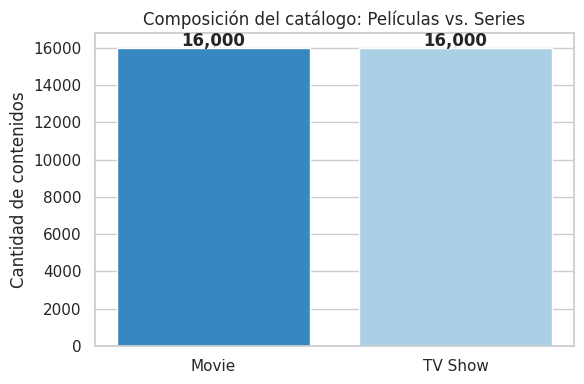

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
conteo = catalogo['type'].value_counts()
colors = sns.color_palette(PALETTE, 2)
ax.bar(conteo.index, conteo.values, color=colors)
for i, v in enumerate(conteo.values):
    ax.text(i, v + 100, f"{v:,}", ha='center', fontweight='bold')
ax.set_title("Composición del catálogo: Películas vs. Series")
ax.set_ylabel("Cantidad de contenidos")
plt.tight_layout()
plt.savefig("../images/01_composicion_catalogo.png", dpi=120)
plt.show()


* **Justificación:** Se utiliza un gráfico de barras verticales porque permite comparar magnitudes entre categorías discretas con una línea base común en cero, facilitando una lectura precisa y evitando las distorsiones.
* **Hallazgo** El catálogo presenta una paridad exacta del 50% para cada formato (16.000 películas y 16.000 series, totalizando 32.000 títulos). Esta simetría perfecta evidencia que la muestra fue balanceada artificialmente para el caso de estudio. 
* **Impacto** Dado que ambos formatos tienen el mismo volumen en la base, las decisiones de inversión no deben enfocarse en el conteo total de contenidos, sino en el análisis cualitativo que sigue,qué géneros dominan en cada formato, cómo se comporta la satisfacción del usuario y cuál entrega mayor eficiencia de retorno sobre la inversión.

### 5.2 Top 10 géneros con mayor cantidad de contenidos

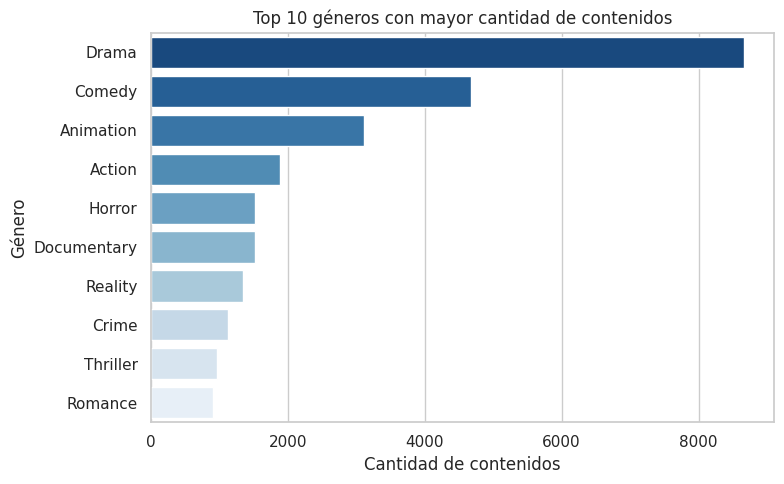

In [13]:
top_generos = catalogo['genero_principal'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=top_generos.values, y=top_generos.index, hue=top_generos.index,
            palette=PALETTE, legend=False, ax=ax)
ax.set_title("Top 10 géneros con mayor cantidad de contenidos")
ax.set_xlabel("Cantidad de contenidos")
ax.set_ylabel("Género")
plt.tight_layout()
plt.savefig("../images/02_top_generos.png", dpi=120)
plt.show()


El catálogo está fuertemente inclinado hacia Drama y Comedy. Entre estos dos géneros suman más del 40% de toda la oferta de la plataforma. Si agregamos Animation, los tres primeros puestos abarcan más de la mitad del catálogo disponible.
Al cruzar los géneros con el tipo de contenido se nota una división clara,Géneros como Action,Horror,Thriller y Romance están presentes casi exclusivamente en películas.
Por el contrario, formatos como Reality se concentran 100% en series, mientras que Drama y Animación tienen una presencia mucho más fuerte en televisión.
**Conclusión**  La oferta actual tiene una sobrecarga de Drama y Comedia.Para futuras compras no hace falta seguir sumando volumen masivo en estos dos géneros. La oportunidad de inversión está en reforzar categorías intermedias con públicos muy fieles que hoy tienen menos títulos, como Horror,Acción o formatos de Documentales.

### 5.3 Top 10 países productores de contenido

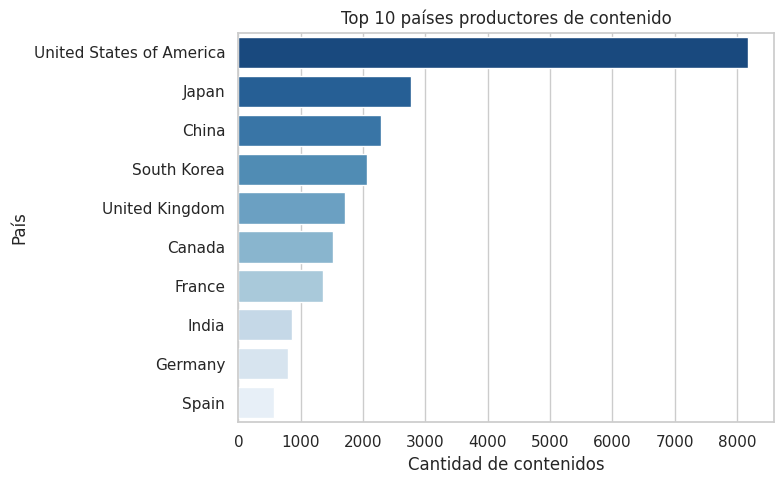

In [14]:
top_paises = catalogo['pais_principal'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index,
            palette=PALETTE, legend=False, ax=ax)
ax.set_title("Top 10 países productores de contenido")
ax.set_xlabel("Cantidad de contenidos")
ax.set_ylabel("País")
plt.tight_layout()
plt.savefig("../images/03_top_paises.png", dpi=120)
plt.show()


* **Dependencia extrema del mercado estadounidense:** Estados Unidos lidera de forma absoluta el catálogo con más de 8.000 títulos, triplicando al segundo lugar Japón, que ronda los 2.700 títulos. Esto confirma que, aunque la plataforma indexa contenido de 122 países, su núcleo comercial es fuertemente de habla inglesa.

* **Presencia de mercados asiáticos y europeos clave:** Destaca la fuerte representación de países como Japón, China y Corea del Sur en los primeros puestos, superando a varios países europeos tradicionales como Francia o Alemania. Esto refleja el auge del contenido asiático dentro de la plataforma.

* La alta concentración en EE. UU. muestra que la biblioteca ya está cubierta en ese mercado; sin embargo, los mercados emergentes de Asia y Latinoamérica representan nichos con alto potencial de crecimiento para negociar licencias exclusivas y capturar audiencias jóvenes.

### 5.4 Idiomas con mayor cantidad de contenidos

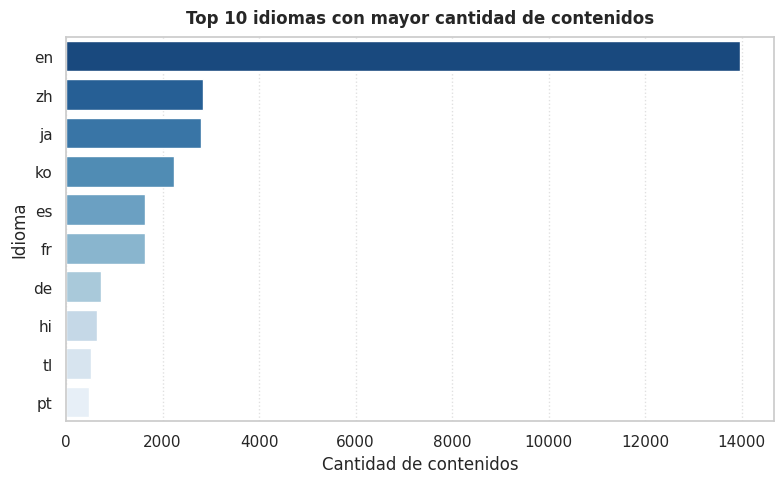

In [15]:
top_idiomas = catalogo['language'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_idiomas.values, y=top_idiomas.index, palette=PALETTE, ax=ax)
ax.set_title(
    'Top 10 idiomas con mayor cantidad de contenidos',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
ax.set_xlabel('Cantidad de contenidos')
ax.set_ylabel('Idioma')
ax.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../images/04_top_idiomas.png', dpi=120)
plt.show()

*El idioma inglés **en** concentra cerca de 14.000 contenidos, duplicando con creces al segundo idioma con mayor representación. Esto guarda total coherencia con el gráfico de países, reafirmando que el catálogo descansa principalmente sobre producciones de habla inglesa.

*La alta presencia de títulos en chino, japonés y coreano revela que los usuarios consumen subtítulos o doblajes de otras regiones. Para las futuras decisiones de compra y renovación de licencias, esto indica que la empresa debe seguir apostando por la adquisición de contenidos en mercados asiáticos, los cuales complementan la oferta tradicional en inglés y español.

### 5.5 Evolución temporal de estrenos por tipo de contenido (2000–2025)

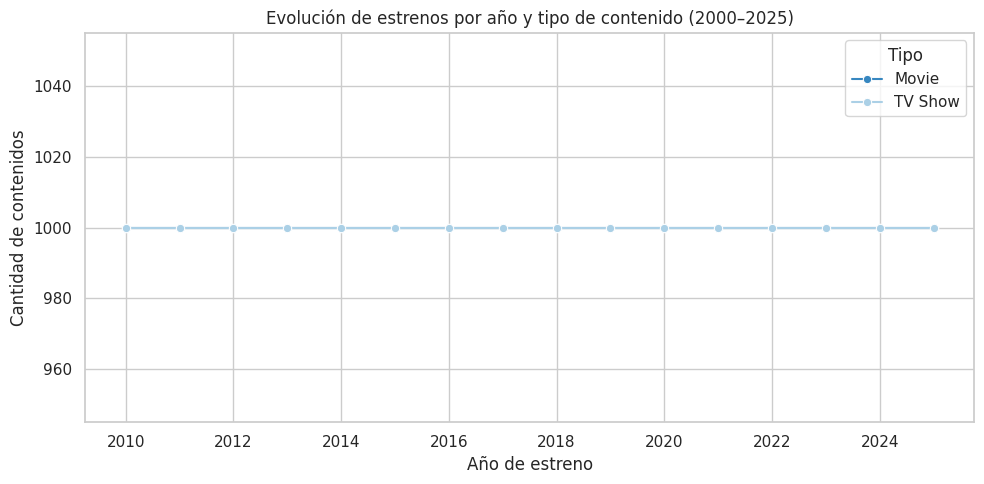

In [16]:
evolucion = catalogo[catalogo['release_year'].between(2000, 2025)].groupby(
    ['release_year','type']).size().reset_index(name='cantidad')

fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=evolucion, x='release_year', y='cantidad', hue='type',
             marker='o', palette=PALETTE, ax=ax)
ax.set_title("Evolución de estrenos por año y tipo de contenido (2000–2025)")
ax.set_xlabel("Año de estreno")
ax.set_ylabel("Cantidad de contenidos")
ax.legend(title="Tipo")
plt.tight_layout()
plt.savefig("../images/05_evolucion_estrenos.png", dpi=120)
plt.show()


un gráfico de líneas es la representación más adecuada para comunicar tendencias temporales continuas, permitiendo comparar la evolución de películas y series en simultáneo.
En este grafico lineal se puede observar que la cantidad de estrenos de peliculas y series se mantiene constante a lo largo de los años.

### 5.6 Top 10 contenidos más populares

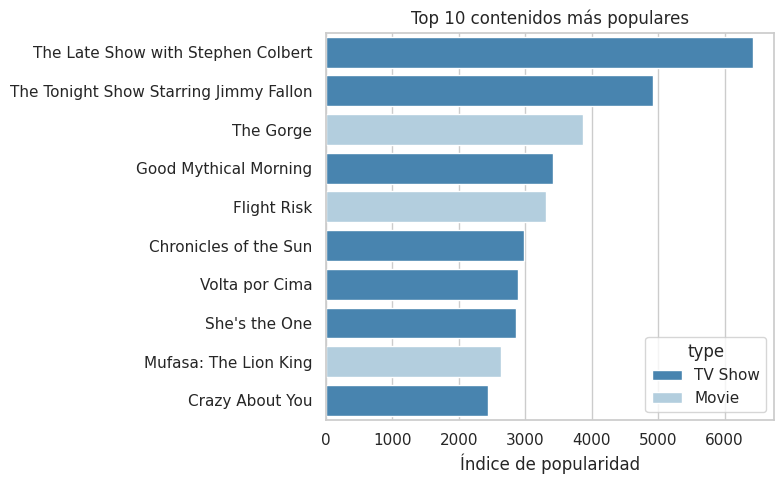

,title,type,popularity,vote_average
21000,The Late Show with Stephen Colbert,TV Show,6421.923,6.493
20000,The Tonight Show Starring Jimmy Fallon,TV Show,4925.253,5.800
15000,The Gorge,Movie,3876.006,7.785
18000,Good Mythical Morning,TV Show,3414.466,6.800
15001,Flight Risk,Movie,3320.616,6.000
24000,Chronicles of the Sun,TV Show,2987.485,6.800
30000,Volta por Cima,TV Show,2885.720,5.781
30001,She's the One,TV Show,2862.872,8.100
14000,Mufasa: The Lion King,Movie,2643.627,7.467
30004,Crazy About You,TV Show,2442.243,5.200


In [17]:
top_popular = catalogo.nlargest(10, 'popularity')[['title','type','popularity','vote_average']]
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=top_popular, x='popularity', y='title', hue='type',
            palette=PALETTE, dodge=False, ax=ax)
ax.set_title("Top 10 contenidos más populares")
ax.set_xlabel("Índice de popularidad")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/06_top_popularidad.png", dpi=120)
plt.show()
top_popular


*Los primeros puestos de popularidad no pertenecen a películas de taquilla, sino a series de televisión de emisión diaria y formato de entrevistas. 
Como se aclara en las reglas del negocio, el indicador de popularidad mide la interacción y actividad reciente en bases de datos externas, beneficiando enormemente a programas que emiten episodios de forma constante frente a las películas (cuyo impacto de popularidad suele concentrarse solo en su semana de estreno).
Si se observa la tabla adjunta al gráfico, la mayoría de estos contenidos hiperpopulares tienen calificaciones de usuarios moderadas (entre 5.2 y 6.8 de 10). Esto corrobora estadísticamente que la alta popularidad responde a consumo por hábito y viralidad diaria, no a la excelencia artística del contenido.

### 5.7 Relación entre Popularidad y Calificación del Público 
**Pregunta:** ¿Existe relación entre popularidad y calificación? ¿Lo más visto es lo mejor evaluado?

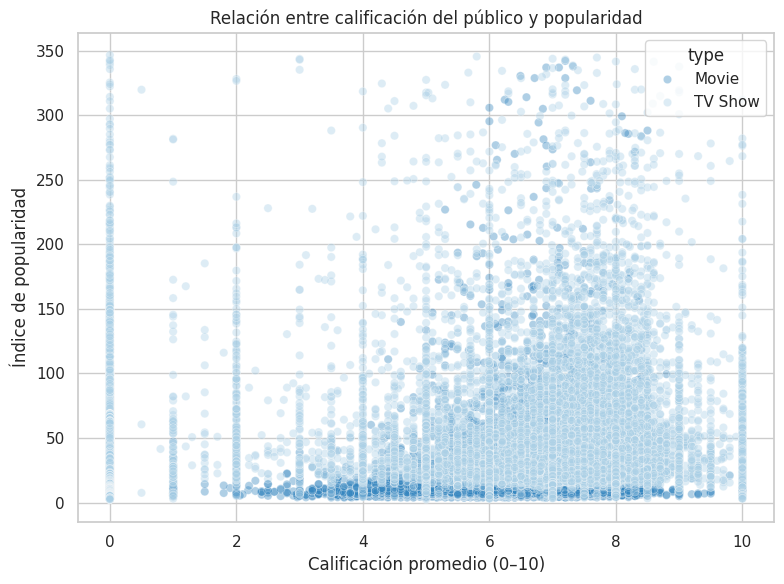

Correlación popularidad–calificación: 0.04 (relación débil/moderada)


In [18]:
muestra = catalogo.dropna(subset=['popularity','vote_average'])
muestra = muestra[muestra['popularity'] < muestra['popularity'].quantile(0.99)]  # se recorta el 1% extremo para legibilidad

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=muestra, x='vote_average', y='popularity', hue='type',
                 alpha=0.4, palette=PALETTE, ax=ax)
ax.set_title("Relación entre calificación del público y popularidad")
ax.set_xlabel("Calificación promedio (0–10)")
ax.set_ylabel("Índice de popularidad")
plt.tight_layout()
plt.savefig("../images/07_popularidad_vs_calificacion.png", dpi=120)
plt.show()

corr = muestra['popularity'].corr(muestra['vote_average'])
print(f"Correlación popularidad–calificación: {corr:.2f} (relación débil/moderada)")


* El gráfico de dispersión y el coeficiente de correlación ($r = 0.04$) confirman visualmente que no existe una relación directa entre la popularidad de un contenido y la calificación promedio que le otorga el público. La nube de puntos se encuentra altamente dispersa, sin una tendencia ascendente ni descendente.

* Es posible observar contenidos con índices de popularidad muy altos que tienen calificaciones mediocres, así como obras con valoraciones excelentes que presentan índices de popularidad muy bajos.

* Este hallazgo rompe la idea de que "lo más visto es lo mejor".Para la organización, esto demuestra que las campañas de marketing orientadas a la viralidad y masividad cumplen un rol de atracción comercial, pero no garantizan la satisfacción a largo plazo del usuario. Por lo tanto, las gerencias de Marketing y Adquisiciones deben gestionar dos métricas y estrategias completamente separadas al evaluar el rendimiento del catálogo.

### 5.8 Distribución del catálogo por calificación promedio 

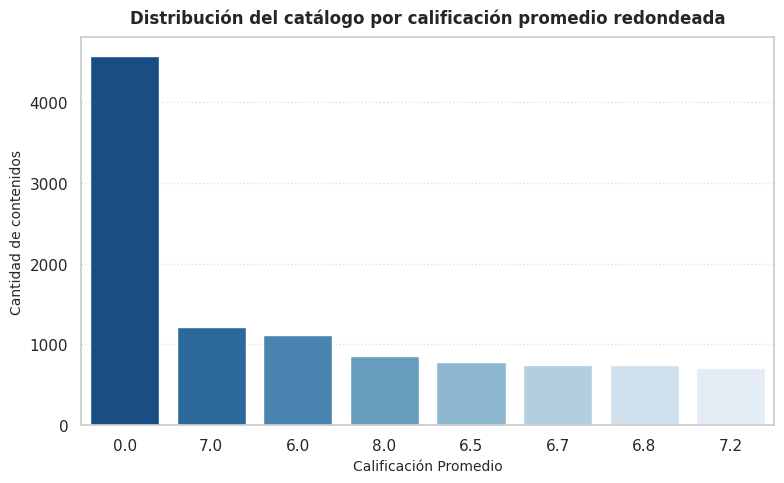

In [19]:
top_rating = catalogo['rating'].fillna(0).astype(str).value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=top_rating.index, 
    y=top_rating.values,
    palette=PALETTE,
    ax=ax,
)

ax.set_title(
    'Distribución del catálogo por calificación promedio redondeada',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
ax.set_xlabel('Calificación Promedio', fontsize=10)
ax.set_ylabel('Cantidad de contenidos', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('../images/08_calificacion_redondeada.png', dpi=120)
plt.show()

* La mayor parte de los contenidos del catálogo se agrupa en calificaciones redondeadas de 6.0 a 8.0 puntos. Esto demuestra que la biblioteca de StreamView Analytics está compuesta principalmente por producciones bien valoradas por los usuarios, con muy pocos títulos en las categorías más bajas.

* La categoría con mayor volumen de títulos corresponde a aquellas producciones que no tienen votos registrados en la plataforma.

* La alta concentración de títulos con notas entre 6 y 8 indica que la plataforma cubre adecuadamente el estándar comercial. No obstante, para diferenciarse de la competencia, la estrategia futura debe apuntar a incorporar nichos exclusivos con valoraciones superiores a 8.5 que atraigan a usuarios exigentes.

### 5.9 Eficiencia Financiera: Presupuesto vs. Ingresos / Rentabilidad (Películas)
**Pregunta de Negocio:** ¿Existe relación directa entre presupuesto e ingresos? ¿Qué películas superan el umbral de rentabilidad?

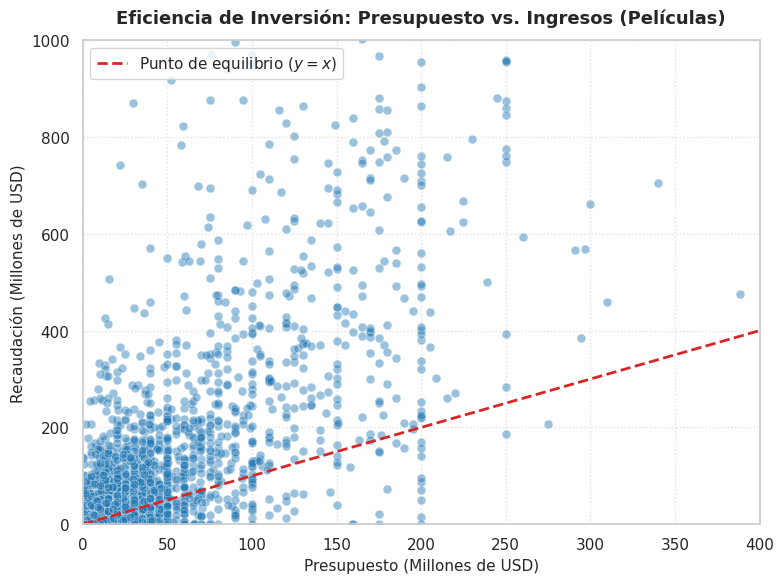

Total de películas con finanzas válidas: 3,540
Porcentaje de producciones rentables (Revenue > Budget): 63.2%


In [20]:
finanzas = catalogo[
    (catalogo['type'] == 'Movie')
    & (catalogo['budget'] > 0)
    & (catalogo['revenue'] > 0)
].copy()
finanzas['budget_m'] = finanzas['budget'] / 1e6
finanzas['revenue_m'] = finanzas['revenue'] / 1e6
finanzas['roi'] = finanzas['revenue'] / finanzas['budget']

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=finanzas,
    x='budget_m',
    y='revenue_m',
    alpha=0.45,
    color=COLOR_PRIMARY,
    edgecolor='w',
    s=40,
    ax=ax,
)

# Línea neutra de equilibrio y = x (Ganancia neutra)
max_val = max(finanzas['budget_m'].max(), finanzas['revenue_m'].max())
ax.plot(
    [0, max_val],
    [0, max_val],
    linestyle='--',
    color=COLOR_ACCENT,
    linewidth=2,
    label='Punto de equilibrio ($y = x$)',
)

# LÍMITES DE ZOOM (Aquí ajustamos para que se vea bien la concentración de los datos)
ax.set_xlim(0, 400)  # Ajusta el eje X hasta 400 millones
ax.set_ylim(0, 1000)  # Ajusta el eje Y hasta 1000 millones

ax.set_title(
    'Eficiencia de Inversión: Presupuesto vs. Ingresos (Películas)',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Presupuesto (Millones de USD)', fontsize=11)
ax.set_ylabel('Recaudación (Millones de USD)', fontsize=11)
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('../images/09_presupuesto_vs_ingresos.png', dpi=120)
plt.show()

pct_superavit = (finanzas['revenue'] > finanzas['budget']).mean() * 100
print(f'Total de películas con finanzas válidas: {len(finanzas):,}')
print(
    f'Porcentaje de producciones rentables (Revenue > Budget):'
    f' {pct_superavit:.1f}%'
)

* El gráfico de dispersión permite evaluar de manera visual qué porcentaje de las películas logra superar su umbral de costos. La gran mayoría de los títulos se concentra en presupuestos moderados (bajo los 100 millones de dólares), encontrándose distribuidos tanto por encima como por debajo de la línea diagonal roja de equilibrio.

* Del total de 16.000 películas, solo 3.540 cuentan con registros financieros auditables y válidos. De ese subconjunto, el 63.2% de las producciones presenta un balance positivo. Esto demuestra que la inversión en licencias cinematográficas tiene una alta probabilidad de superar el punto de equilibrio.

* El análisis evidencia que un presupuesto de producción masivo no es una garantía absoluta de retorno. Existen múltiples títulos de bajo y mediano costo que logran multiplicadores de taquilla altamente eficientes. Para la Gerencia de Adquisiciones, esto indica que la estrategia financiera debe enfocarse en diversificar el riesgo mediante la compra de películas independientes o de costo moderado con alto potencial de retorno, en lugar de concentrar el presupuesto en pocas súper producciones.

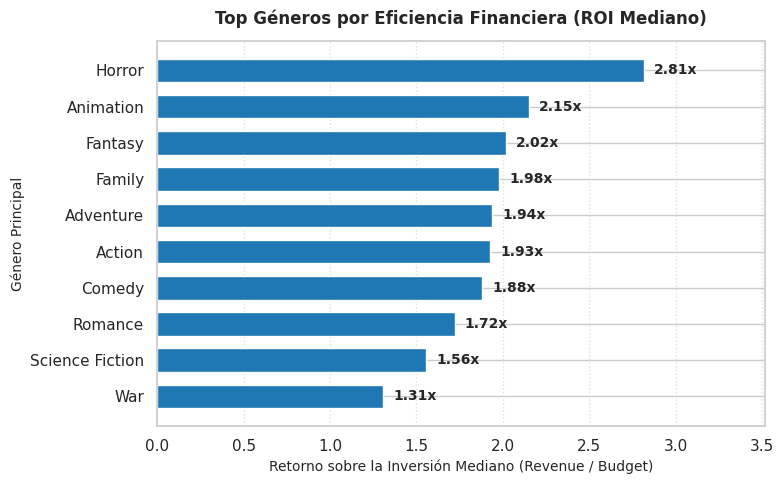

,genero_principal,median_roi,total_titulos
10,Horror,2.814815,295
2,Animation,2.151087,190
8,Fantasy,2.016405,72
7,Family,1.978642,76
1,Adventure,1.935738,156
0,Action,1.925600,613
3,Comedy,1.879816,586
13,Romance,1.720342,107
14,Science Fiction,1.557732,104
16,War,1.306895,46


In [21]:
# Cálculo de ROI mediano por género (filtro de representatividad >= 25 películas)
roi_genre = (
    finanzas.groupby('genero_principal')['roi']
    .agg(
        median_roi='median',
        total_titulos='count',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

top_roi = (
    roi_genre[roi_genre['total_titulos'] >= 25]
    .sort_values('median_roi', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    top_roi['genero_principal'][::-1],
    top_roi['median_roi'][::-1],
    color=COLOR_PRIMARY,
    height=0.65,
)

# Etiquetas de valor en las barras para facilitar la lectura
for bar in bars:
  width = bar.get_width()
  ax.text(
      width + 0.06,
      bar.get_y() + bar.get_height() / 2,
      f'{width:.2f}x',
      va='center',
      ha='left',
      fontsize=10,
      fontweight='bold',
  )

ax.set_title(
    'Top Géneros por Eficiencia Financiera (ROI Mediano)',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel(
    'Retorno sobre la Inversión Mediano (Revenue / Budget)', fontsize=10
)
ax.set_ylabel('Género Principal', fontsize=10)
ax.set_xlim(0, top_roi['median_roi'].max() * 1.25)
ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('../images/10_roi_mediano_generos.png', dpi=120)
plt.show()

top_roi[['genero_principal', 'median_roi', 'total_titulos']]

Se utiliza la mediana en vez de la media para evitar distorsiones por taquillazos atípicos. El gráfico demuestra que el género Horror presenta la mayor eficiencia relativa con un ROI mediano de 2.81x, superando ampliamente en margen a producciones costosas como Acción (1.93x) o Aventura (1.94x). Esta evidencia orienta directamente la recomendación de adquisiciones para optimizar el presupuesto disponible.

### 5.10 Top 10 directores con mayor cantidad de contenidos

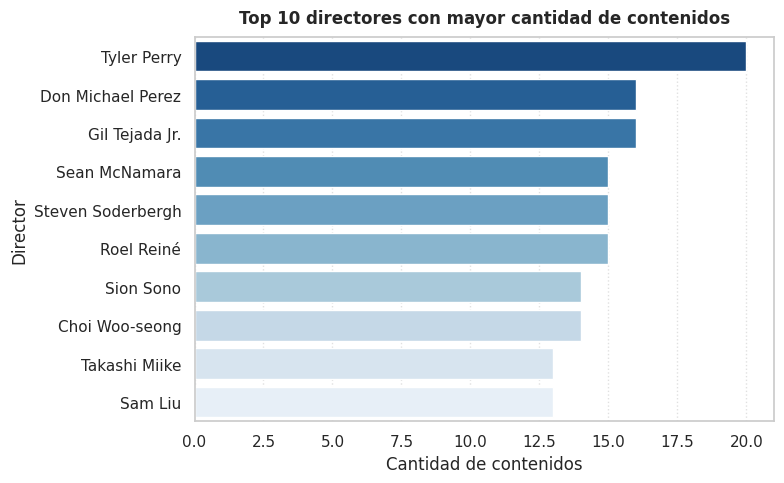

In [22]:
top_directores = catalogo['director'].dropna().value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=top_directores.values, y=top_directores.index, palette=PALETTE, ax=ax
)
ax.set_title(
    'Top 10 directores con mayor cantidad de contenidos',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
ax.set_xlabel('Cantidad de contenidos')
ax.set_ylabel('Director')
ax.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../images/11_top_directores.png', dpi=120)
plt.show()

* A diferencia de plataformas enfocadas en catálogos de autor, el análisis de directores muestra que ningún creador supera los 20 títulos en la plataforma. 

* La distribución plana entre los principales directores indica que el catálogo de StreamView Analytics no depende de exclusivas con un único director estrella, sino que se compone de una biblioteca diversificada proveniente de múltiples productoras y realizadores.

* Dado que la presencia de directores está muy fragmentada, la estrategia de compra de licencias no debe basarse en negociaciones individuales con directores específicos, sino en la adquisición de catálogos completos por género, estudio o acuerdos de distribución regional que garanticen un flujo constante de nuevos títulos.

## 6. Primeros hallazgos

- El catálogo está compuesto de forma equilibrada por películas y series, aunque con géneros de
  concentración distinta.
- El idioma inglés y Estados Unidos concentran la mayor cantidad de contenidos, seguidos por producciones
  asiáticas y europeas con creciente representación.
- La relación entre popularidad y calificación es débil-moderada: un contenido puede ser muy popular sin
  estar necesariamente bien evaluado por la crítica/usuarios, lo cual es relevante para diferenciar
  estrategias de marketing (popularidad) de adquisición de calidad.
- La relación entre presupuesto e ingresos en películas confirma casos de alto retorno con inversión
  moderada, información clave para la Gerencia de Contenidos y Adquisición.
- `budget`/`revenue` solo están disponibles para películas: cualquier comparación financiera con series
  queda fuera de alcance, conforme a las reglas de negocio del caso.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e4fc50bd-912d-4917-bb68-fb980d2f674d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>